<a href="https://colab.research.google.com/github/1011-zion/-/blob/main/Untitled7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

解壓完成

image 1/1 /content/images/images/images/images/Cars74.png: 448x640 1 bus, 69.8ms
Speed: 10.7ms preprocess, 69.8ms inference, 35.8ms postprocess per image at shape (1, 3, 448, 640)
Cars74.png → CZi7 Kod

image 1/1 /content/images/images/images/images/Cars272.png: 288x640 2 cars, 1 bus, 73.0ms
Speed: 3.0ms preprocess, 73.0ms inference, 1.8ms postprocess per image at shape (1, 3, 288, 640)
Cars272.png → RXGL GDU

image 1/1 /content/images/images/images/images/Cars47.png: 480x640 2 cars, 1 chair, 82.9ms
Speed: 2.8ms preprocess, 82.9ms inference, 4.5ms postprocess per image at shape (1, 3, 480, 640)
Cars47.png → NOT_FOUND

image 1/1 /content/images/images/images/images/Cars129.png: 512x640 2 cars, 71.0ms
Speed: 4.5ms preprocess, 71.0ms inference, 1.8ms postprocess per image at shape (1, 3, 512, 640)
Cars129.png → OPEC Loi

image 1/1 /content/images/images/images/images/Cars293.png: 448x640 1 car, 10.1ms
Speed: 2.8ms preprocess, 10.1ms inference, 2.1ms postprocess per image at shape (1

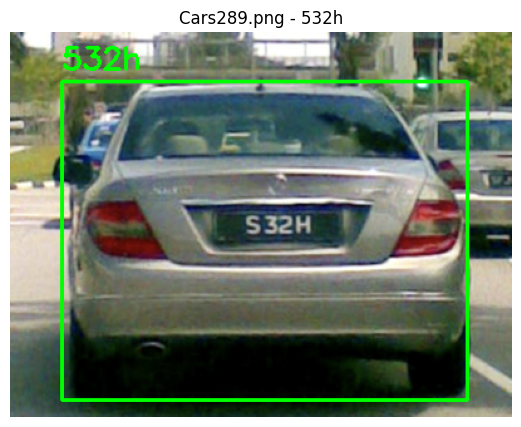

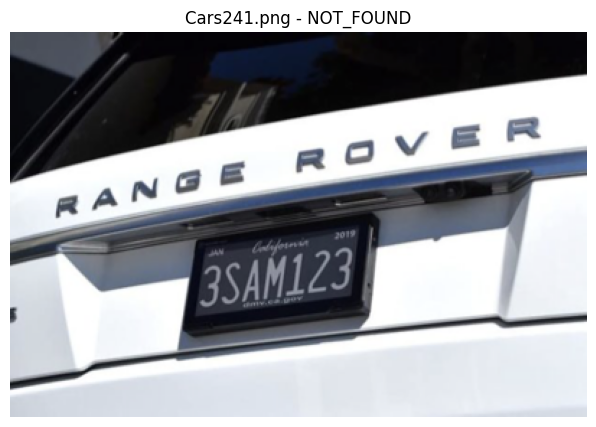

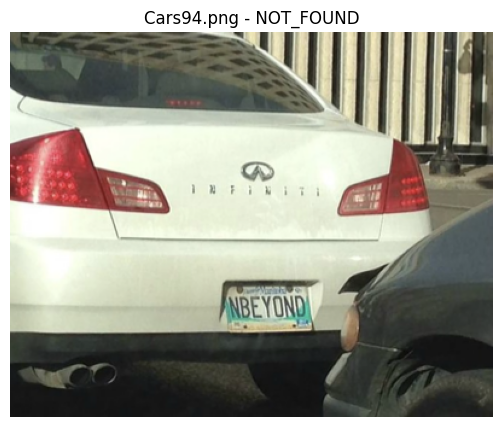

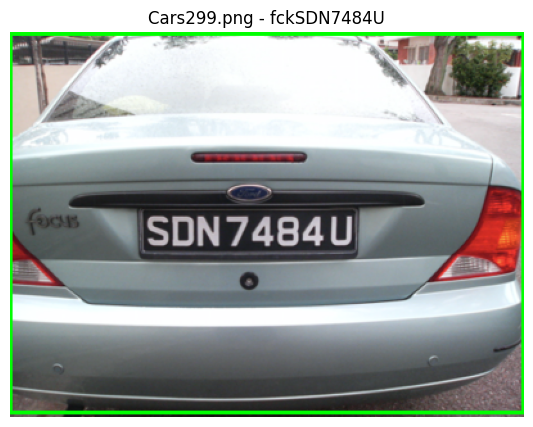

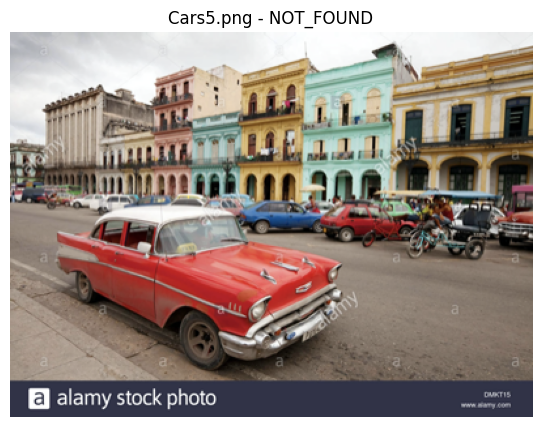

In [2]:
# 多張車輛辨識車牌號碼程式
# 安裝套件
!pip install ultralytics easyocr -q
import zipfile
import os
import cv2
import random
import matplotlib.pyplot as plt
from ultralytics import YOLO
import easyocr
# 解壓 ZIP
zip_path = "/content/images.zip"
extract_path = "/content/images/images/images/images"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("解壓完成")

# 載入模型
model = YOLO("yolov8n.pt")
reader = easyocr.Reader(['en'])
# 輸出檔案
output_file = "car_OK.txt"
# 用來存「顯示用結果」
results_list = []
# 批次辨識
with open(output_file, "w", encoding="utf-8") as f:
    for img_name in os.listdir(extract_path):
        if not img_name.lower().endswith(('.jpg', '.png', '.jpeg')):
            continue
        img_path = os.path.join(extract_path, img_name)
        img = cv2.imread(img_path)
        if img is None:
            continue
        # YOLO 偵測
        results = model(img_path)
        plate_text = "NOT_FOUND"
        for r in results:
            for box in r.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                x1, y1 = max(0, x1), max(0, y1)
                x2, y2 = min(img.shape[1], x2), min(img.shape[0], y2)
                crop = img[y1:y2, x1:x2]
                ocr_result = reader.readtext(crop)
                text = "".join([t[1] for t in ocr_result]).strip()
                if text != "":
                    plate_text = text
                    cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0), 2)
                    cv2.putText(img, text, (x1, y1-10),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.8,
                                (0,255,0), 2)
                    break
        # 寫入 txt
        f.write(f"{img_name}\t{plate_text}\n")
        # 存起來給「隨機顯示用」
        results_list.append((img_name, img, plate_text))
        print(f"{img_name} → {plate_text}")

# 隨機顯示 5 張結果
sample_results = random.sample(results_list, min(5, len(results_list)))
for img_name, img, text in sample_results:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8,5))
    plt.imshow(img_rgb)
    plt.title(f"{img_name} - {text}")
    plt.axis("off")
    plt.show()